# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Q1 Answers:**

1. We use them to model non linear relationships and bounded outcomes (like probabilities between 0 and 1). Linear models can predict values outside valid ranges, while GLMs with activation functions (like the logistic function) constrain predictions to appropriate ranges and capture non linear patterns in data.

2. Cross entropy is effective because it measures how well predicted probabilities match actual class labels. It heavily penalizes confident wrong predictions, encouraging the model to output well calibrated probabilities. It's also the negative log likelihood, making it theoretically grounded in maximum likelihood estimation.

3. Can be both true and false because logistic regression is linear in the log odds (logit) space but non linear in the probability space. The relationship between features and log odds is linear ($\log(p/(1-p)) = b_0 + b_1x_1 + ...$), but the relationship between features and probability is non linear due to the logistic function.

4. False, logistic regression is specifically designed for classification. It predicts probabilities that can be converted to class labels using a threshold (typically 0.5). It's one of the most common classification algorithms.

5. No the coefficient represents the change in log odds for a 1 unit change in the feature, not the change in predicted probability. The effect on probability depends on the current probability value - the same coefficient change has different effects at different points on the logistic curve.

6. False, feature engineering is still valuable for logistic regression. While the logistic function adds non linearity in how we map to probabilities, the model is still linear in the features. Creating interaction terms, polynomial features, or other engineered features can capture complex relationships the base model cannot.

7. False, Use logistic regression for binary/categorical outcomes and linear regression for continuous outcomes. Logistic regression is not universally better it's designed for different problems. For predicting continuous values, linear regression is more appropriate. Choose the model based on your outcome variable and problem type.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
np.random.seed(42)

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolonseparated.

The relevant variables are:
 `Debtor`  `1` if the student has outstanding debt and `0` otherwise
 `Tuition fees up to date`  `1` if tuition is up to date and `0` otherwise
 `Scholarship holder`  `1` if the student has a scholarship and `0` otherwise
 `Age at enrollment`  student's age when entering the program
 `Curricular units 1st sem (approved)`  number of firstsemester courses passed
 `Target`  `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [31]:
#Q2.1
data = pd.read_csv('./data/data.csv', sep=';')

print(f"Original data shape: {data.shape}")
print(f"\nTarget distribution:")
print(data['Target'].value_counts())

#relevant columns
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = data[cols].copy()

#check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# drop rows with missing values
df = df.dropna()
print(f"\nData shape after handling missing values: {df.shape}")

#binary target: 1 = Dropout, 0 = graduate or Enrolled
df['Dropout'] = (df['Target'] == 'Dropout').astype(int)

print(f"\nBinary target distribution:")
print(df['Dropout'].value_counts())
print(f"Dropout rate: {df['Dropout'].mean():.2%}")

display(df.head())

Original data shape: (4424, 37)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Missing values:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Data shape after handling missing values: (4424, 6)

Binary target distribution:
Dropout
0    3003
1    1421
Name: count, dtype: int64
Dropout rate: 32.12%


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [45]:
#Q2.2
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Dropout']

# fit logistic regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X, y)

# display coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
})

print("Q2.2: Logistic Regression Coefficients")
print(f"Intercept: {log_reg.intercept_[0]:.4f}\n")
display(coef_df)

print("\n**Interpretation:**")
print("\nPositive coefficients (increase dropout probability):")
for idx, row in coef_df[coef_df['Coefficient'] > 0].iterrows():
    print(f"  - {row['Feature']}: coef = {row['Coefficient']:.4f}, OR = {row['Odds Ratio']:.4f}")

print("\nNegative coefficients (decrease dropout probability):")
for idx, row in coef_df[coef_df['Coefficient'] < 0].iterrows():
    print(f"  - {row['Feature']}: coef = {row['Coefficient']:.4f}, OR = {row['Odds Ratio']:.4f}")

tuition_coef = coef_df[coef_df['Feature'] == 'Tuition fees up to date']['Coefficient'].values[0]
if tuition_coef < 0:
    print(f"\n**Yes**, being up to date on tuition reduces dropout risk (coef = {tuition_coef:.4f}).")
else: 
    print(f"\n**No**, being up to date on tuition does not reduce dropout risk (coef = {tuition_coef:.4f}).")

Q2.2: Logistic Regression Coefficients
Intercept: 0.4857



,Feature,Coefficient,Odds Ratio
0,Debtor,0.5306,1.7000
1,Tuition fees up to date,-2.5565,0.0776
2,Scholarship holder,-1.2274,0.2930
3,Age at enrollment,0.0499,1.0512



**Interpretation:**

Positive coefficients (increase dropout probability):
  - Debtor: coef = 0.5306, OR = 1.7000
  - Age at enrollment: coef = 0.0499, OR = 1.0512

Negative coefficients (decrease dropout probability):
  - Tuition fees up to date: coef = -2.5565, OR = 0.0776
  - Scholarship holder: coef = -1.2274, OR = 0.2930

**Yes**, being up to date on tuition reduces dropout risk (coef = -2.5565).


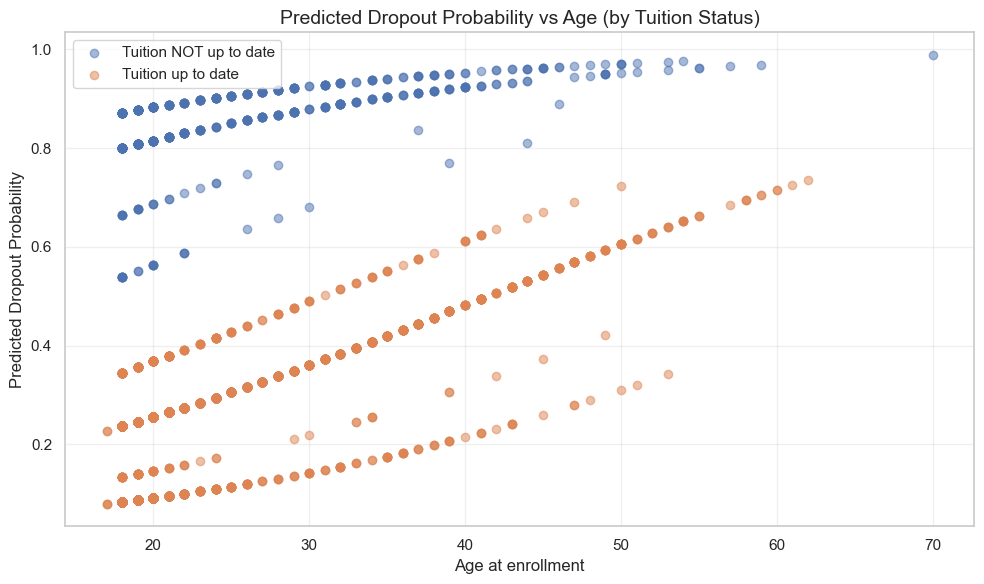


Average predicted dropout probability:
  - Tuition up to date: 24.81%
  - Tuition NOT up to date: 86.07%
  - Average effect: -61.26%

Effect of tuition by age group:
  - <20: -60.44%
  - 20-25: -60.20%
  - 25-30: -55.62%
  - 30+: -48.01%

Being up to date on tuition reduces dropout most for age group: <20


In [33]:
#Q2.3
df['Pred_Dropout_Prob'] = log_reg.predict_proba(X)[:, 1]

#plot
plt.figure(figsize=(10, 6))
for tuition_status in [0, 1]:
    mask = df['Tuition fees up to date'] == tuition_status
    label = 'Tuition up to date' if tuition_status == 1 else 'Tuition NOT up to date'
    plt.scatter(df[mask]['Age at enrollment'], 
               df[mask]['Pred_Dropout_Prob'],
               alpha=0.5, label=label)

plt.xlabel('Age at enrollment', fontsize=12)
plt.ylabel('Predicted Dropout Probability', fontsize=12)
plt.title('Predicted Dropout Probability vs Age (by Tuition Status)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  average effect of tuition
tuition_paid = df[df['Tuition fees up to date'] == 1]['Pred_Dropout_Prob'].mean()
tuition_not_paid = df[df['Tuition fees up to date'] == 0]['Pred_Dropout_Prob'].mean()
avg_effect = tuition_paid - tuition_not_paid

print(f"\nAverage predicted dropout probability:")
print(f"  - Tuition up to date: {tuition_paid:.2%}")
print(f"  - Tuition NOT up to date: {tuition_not_paid:.2%}")
print(f"  - Average effect: {avg_effect:.2%}")

#Analyze by age groups
df['Age_Group'] = pd.cut(df['Age at enrollment'], bins=[0, 20, 25, 30, 100], 
                          labels=['<20', '20-25', '25-30', '30+'])
age_effect = df.groupby('Age_Group').apply(
    lambda x: x[x['Tuition fees up to date']==1]['Pred_Dropout_Prob'].mean() - 
              x[x['Tuition fees up to date']==0]['Pred_Dropout_Prob'].mean()
)

print(f"\nEffect of tuition by age group:")
for age, effect in age_effect.items():
    print(f"  - {age}: {effect:.2%}")

max_effect_age = age_effect.idxmin()
print(f"\nBeing up to date on tuition reduces dropout most for age group: {max_effect_age}")

In [34]:
#Q2.4
y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

print("Q2.4: Confusion Matrix")
print("\nConfusion Matrix:")
cm_df = pd.DataFrame(cm,index=['Actual: Not Dropout', 'Actual: Dropout'],
columns=['Predicted: Not Dropout', 'Predicted: Dropout'])
display(cm_df)

print(f"\nAccuracy: {accuracy:.2%}")
print(f"\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Not Dropout', 'Dropout']))

Q2.4: Confusion Matrix

Confusion Matrix:


,Predicted: Not Dropout,Predicted: Dropout
Actual: Not Dropout,2841,162
Actual: Dropout,891,530



Accuracy: 76.20%

Classification Report:
              precision    recall  f1-score   support

 Not Dropout       0.76      0.95      0.84      3003
     Dropout       0.77      0.37      0.50      1421

    accuracy                           0.76      4424
   macro avg       0.76      0.66      0.67      4424
weighted avg       0.76      0.76      0.73      4424



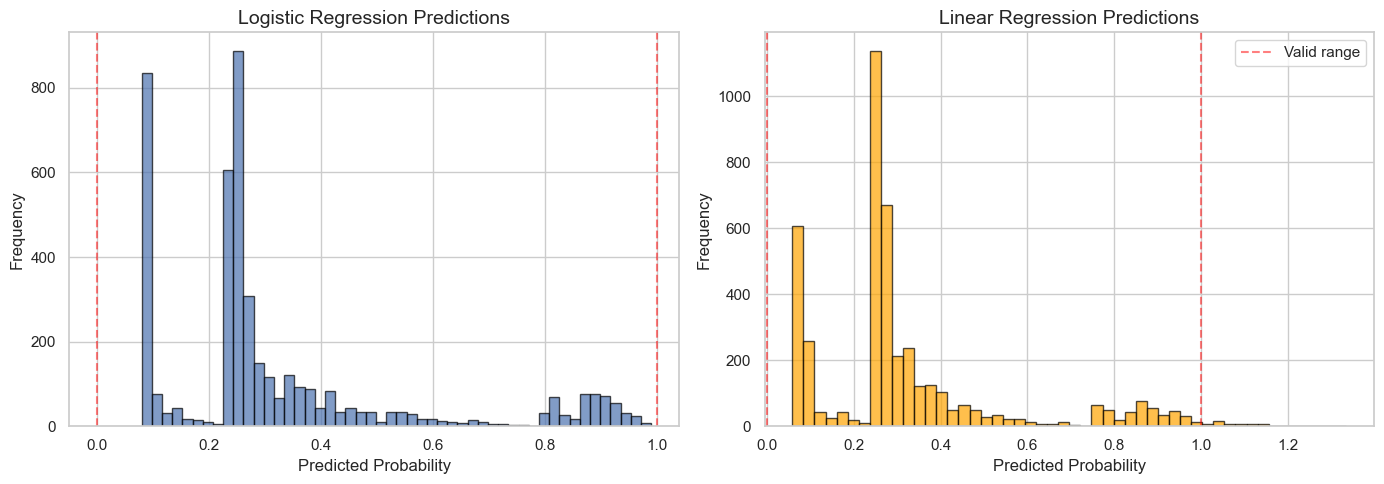


**Comparison:**

Logistic Regression:
  - Min prediction: 0.0795
  - Max prediction: 0.9891
  - All predictions in [0,1]: Yes

Linear Regression:
  - Min prediction: 0.0583
  - Max prediction: 1.3350
  - Invalid predictions (outside [0,1]): 57 (1.3%)

**Logistic regression is better** because it guarantees predictions in [0,1],
which is appropriate for probabilities. Linear regression can produce invalid probabilities.


In [35]:
# Q2.5
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)

#clip linear predictions to [0, 1] for comparison
y_pred_linear_clipped = np.clip(y_pred_linear, 0, 1)

# histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Pred_Dropout_Prob'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Logistic Regression Predictions', fontsize=14)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(1, color='red', linestyle='--', alpha=0.5)

axes[1].hist(y_pred_linear, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Linear Regression Predictions', fontsize=14)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5, label='Valid range')
axes[1].axvline(1, color='red', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n**Comparison:**")
print(f"\nLogistic Regression:")
print(f"  - Min prediction: {df['Pred_Dropout_Prob'].min():.4f}")
print(f"  - Max prediction: {df['Pred_Dropout_Prob'].max():.4f}")
print(f"  - All predictions in [0,1]: Yes")

print(f"\nLinear Regression:")
print(f"  - Min prediction: {y_pred_linear.min():.4f}")
print(f"  - Max prediction: {y_pred_linear.max():.4f}")
invalid_preds = ((y_pred_linear < 0) | (y_pred_linear > 1)).sum()
print(f"  - Invalid predictions (outside [0,1]): {invalid_preds} ({invalid_preds/len(y_pred_linear):.1%})")

print(f"\n**Logistic regression is better** because it guarantees predictions in [0,1],")
print(f"which is appropriate for probabilities. Linear regression can produce invalid probabilities.")

In [44]:
#Q2.6
print("Q2.6: At Risk Students and Interventions")
print("\n**Most at risk students:**")

#Identify high risk profile
high_risk = df[df['Pred_Dropout_Prob'] > 0.5].copy()
print(f"\nNumber of high risk students (>50% dropout probability): {len(high_risk)}")
print(f"Percentage of total: {len(high_risk)/len(df):.1%}")

print(f"\nCharacteristics of high risk students:")
print(f"  - Debtor: {high_risk['Debtor'].mean():.1%}")
print(f"  - Tuition up to date: {high_risk['Tuition fees up to date'].mean():.1%}")
print(f"  - Scholarship holder: {high_risk['Scholarship holder'].mean():.1%}")
print(f"  - Average age: {high_risk['Age at enrollment'].mean():.1f}")

print(f"\n**Recommended interventions:**")
print(f"\n1. **Financial support programs**: Students with debt and overdue tuition are at high risk.")
print(f"   - Emergency grants or loans")
print(f"   - Flexible payment plans")
print(f"   - Increase scholarship availability")

print(f"\n2. **Early warning system**: Identify at risk students early based on:")
print(f"   - Financial status (debt, tuition payment)")
print(f"   - Age (non traditional students may need different support)")
print(f"   - Scholarship status")

print(f"\n3. **Targeted support services**:")
print(f"   - Academic advising and tutoring")
print(f"   - Financial literacy workshops")
print(f"   - Peer mentoring programs")
print(f"   - Flexible scheduling for older students")

print(f"\n4. **Proactive outreach**: Contact high risk students before they consider dropping out")
print(f"   to connect them with resources and support.")

Q2.6: At Risk Students and Interventions

**Most at risk students:**

Number of high risk students (>50% dropout probability): 692
Percentage of total: 15.6%

Characteristics of high risk students:
  - Debtor: 40.5%
  - Tuition up to date: 23.7%
  - Scholarship holder: 6.6%
  - Average age: 31.4

**Recommended interventions:**

1. **Financial support programs**: Students with debt and overdue tuition are at high risk.
   - Emergency grants or loans
   - Flexible payment plans
   - Increase scholarship availability

2. **Early warning system**: Identify at risk students early based on:
   - Financial status (debt, tuition payment)
   - Age (non traditional students may need different support)
   - Scholarship status

3. **Targeted support services**:
   - Academic advising and tutoring
   - Financial literacy workshops
   - Peer mentoring programs
   - Flexible scheduling for older students

4. **Proactive outreach**: Contact high risk students before they consider dropping out
   to co

In [37]:
#Q2.7
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

#fit multinomial logistic regression
multi_log_reg = LogisticRegression(random_state=42, max_iter=1000)
multi_log_reg.fit(X_multi, y_multi)

#hard classification
y_pred_multi = multi_log_reg.predict(X_multi)

print("Q2.7: Multinomial Logistic Regression")
print("\nConfusion Matrix:")
cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=multi_log_reg.classes_)
cm_multi_df = pd.DataFrame(cm_multi, index=[f'Actual: {c}' for c in multi_log_reg.classes_],
columns=[f'Predicted: {c}' for c in multi_log_reg.classes_])
display(cm_multi_df)

print(f"\nAccuracy: {accuracy_score(y_multi, y_pred_multi):.2%}")

# check predicted classes
print(f"\nClasses in hard predictions:")
print(pd.Series(y_pred_multi).value_counts())
print(f"\nDoes hard classification predict every class? {set(y_pred_multi) == set(multi_log_reg.classes_)}")

# predicted probabilities
y_proba_multi = multi_log_reg.predict_proba(X_multi)
proba_df = pd.DataFrame(y_proba_multi, columns=multi_log_reg.classes_)

print(f"\nPredicted probabilities (first 10 rows):")
display(proba_df.head(10))

print(f"\nProbability statistics by class:")
display(proba_df.describe())

#check if probabilities predict every class
max_proba_class = proba_df.idxmax(axis=1)
print(f"\nClasses with highest probability:")
print(max_proba_class.value_counts())
print(f"\nDo predicted probabilities predict every class? {set(max_proba_class) == set(multi_log_reg.classes_)}")

print(f"\n**Analysis:**")
if set(y_pred_multi) != set(multi_log_reg.classes_):
    missing = set(multi_log_reg.classes_) - set(y_pred_multi)
    print(f"Hard classification does NOT predict all classes. Missing: {missing}")
    print(f"This suggests the model is biased toward the majority class.")
else:
    print(f"Hard classification predicts all classes.")

if set(max_proba_class) != set(multi_log_reg.classes_):
    missing = set(multi_log_reg.classes_) - set(max_proba_class)
    print(f"\nProbabilities do NOT predict all classes as most likely. Missing: {missing}")
else:
    print(f"\nProbabilities predict all classes as most likely for at least some students.")

Q2.7: Multinomial Logistic Regression

Confusion Matrix:


,Predicted: Dropout,Predicted: Enrolled,Predicted: Graduate
Actual: Dropout,1054,0,367
Actual: Enrolled,280,0,514
Actual: Graduate,146,0,2063



Accuracy: 70.46%

Classes in hard predictions:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

Does hard classification predict every class? False

Predicted probabilities (first 10 rows):


,Dropout,Enrolled,Graduate
0,0.6805,0.2105,0.1090
1,0.6954,0.1460,0.1585
2,0.9530,0.0412,0.0058
3,0.1178,0.1770,0.7052
4,0.1842,0.2127,0.6031
5,0.3084,0.3234,0.3681
6,0.0719,0.1406,0.7874
7,0.9530,0.0412,0.0058
8,0.1178,0.1770,0.7052
9,0.8389,0.1230,0.0381



Probability statistics by class:


,Dropout,Enrolled,Graduate
count,4.4240e+03,4424.0000,4424.0000
mean,3.2122e-01,0.1795,0.4993
std,2.8669e-01,0.0663,0.2876
min,9.5647e-07,0.0003,0.0021
25%,1.1781e-01,0.1406,0.1727
50%,1.8423e-01,0.1770,0.6031
75%,5.8987e-01,0.2127,0.7052
max,9.6016e-01,0.3278,0.9997



Classes with highest probability:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

Do predicted probabilities predict every class? False

**Analysis:**
Hard classification does NOT predict all classes. Missing: {'Enrolled'}
This suggests the model is biased toward the majority class.

Probabilities do NOT predict all classes as most likely. Missing: {'Enrolled'}


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite diuretics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected survival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Run a multinomial logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [38]:
#Q3.1
cirrhosis = pd.read_csv('./data/cirrhosis.csv')

print(f"Original data shape: {cirrhosis.shape}")
print(f"\nColumns: {list(cirrhosis.columns)}")

#select relevant columns
cols_cirrh = ['Status', 'Drug', 'Edema', 'Bilirubin', 'Stage']
cirrh_df = cirrhosis[cols_cirrh].copy()

print(f"\nMissing values:")
print(cirrh_df.isnull().sum())

# handle missing values and drop rows with missing data
cirrh_df = cirrh_df.dropna()
print(f"\nData shape after dropping missing values: {cirrh_df.shape}")

# binary survival target: 1 = Alive (C or CL), 0 = Dead (D)
cirrh_df['Survived'] = cirrh_df['Status'].isin(['C', 'CL']).astype(int)

print(f"\nStatus distribution:")
print(cirrh_df['Status'].value_counts())
print(f"\nSurvival rate: {cirrh_df['Survived'].mean():.2%}")

#  categorical variables
cirrh_df['Drug_Encoded'] = (cirrh_df['Drug'] == 'D-penicillamine').astype(int)

# edema: N=0, S=1, Y=2 (ordinal)
edema_map = {'N': 0, 'S': 1, 'Y': 2}
cirrh_df['Edema_Encoded'] = cirrh_df['Edema'].map(edema_map)

display(cirrh_df.head())
print(f"\nEdema distribution:")
print(cirrh_df['Edema'].value_counts())

Original data shape: (418, 20)

Columns: ['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']

Missing values:
Status         0
Drug         106
Edema          0
Bilirubin      0
Stage          6
dtype: int64

Data shape after dropping missing values: (312, 5)

Status distribution:
Status
C     168
D     125
CL     19
Name: count, dtype: int64

Survival rate: 59.94%


,Status,Drug,Edema,Bilirubin,Stage,Survived,Drug_Encoded,Edema_Encoded
0,D,D-penicillamine,Y,14.5,4.0,0,1,2
1,C,D-penicillamine,N,1.1,3.0,1,1,0
2,D,D-penicillamine,S,1.4,4.0,0,1,1
3,D,D-penicillamine,S,1.8,4.0,0,1,1
4,CL,Placebo,N,3.4,3.0,1,0,0



Edema distribution:
Edema
N    263
S     29
Y     20
Name: count, dtype: int64


In [39]:
#Q3.2
X_cirrh = cirrh_df[['Edema_Encoded', 'Drug_Encoded', 'Bilirubin']]
y_cirrh = cirrh_df['Survived']

log_reg_cirrh = LogisticRegression(random_state=42, max_iter=1000)
log_reg_cirrh.fit(X_cirrh, y_cirrh)

#display coefficients
coef_cirrh_df = pd.DataFrame({
    'Feature': ['Edema', 'Drug (D-penicillamine)', 'Bilirubin'],
    'Coefficient': log_reg_cirrh.coef_[0],
    'Odds Ratio': np.exp(log_reg_cirrh.coef_[0])
})

print("Q3.2: Logistic Regression for Survival")
print(f"Intercept: {log_reg_cirrh.intercept_[0]:.4f}\n")
display(coef_cirrh_df)

print("\n**Interpretation:**")

drug_coef = coef_cirrh_df[coef_cirrh_df['Feature'] == 'Drug (D-penicillamine)']['Coefficient'].values[0]
if drug_coef > 0:
    print(f"\n**Drug effect**: Positive coefficient ({drug_coef:.4f}) suggests D-penicillamine")
    print(f"  INCREASES survival probability.")
else:
    print(f"\n**Drug effect**: Negative coefficient ({drug_coef:.4f}) suggests D-penicillamine")
    print(f"  DECREASES survival probability (or has no benefit).")

bili_coef = coef_cirrh_df[coef_cirrh_df['Feature'] == 'Bilirubin']['Coefficient'].values[0]
if bili_coef > 0:
    print(f"\n**Bilirubin effect**: Positive coefficient ({bili_coef:.4f}) suggests higher")
    print(f"  bilirubin INCREASES survival (unexpected - may indicate data issues).")
else:
    print(f"\n**Bilirubin effect**: Negative coefficient ({bili_coef:.4f}) suggests higher")
    print(f"  bilirubin DECREASES survival (as expected - indicates liver damage).")

edema_coef = coef_cirrh_df[coef_cirrh_df['Feature'] == 'Edema']['Coefficient'].values[0]
if edema_coef > 0:
    print(f"\n**Edema effect**: Positive coefficient ({edema_coef:.4f}) suggests worse edema")
    print(f"  INCREASES survival (unexpected).")
else:
    print(f"\n**Edema effect**: Negative coefficient ({edema_coef:.4f}) suggests worse edema")
    print(f"  DECREASES survival (as expected - indicates disease progression).")

Q3.2: Logistic Regression for Survival
Intercept: 1.6498



,Feature,Coefficient,Odds Ratio
0,Edema,-0.9153,0.4004
1,Drug (D-penicillamine),-0.2235,0.7997
2,Bilirubin,-0.3486,0.7057



**Interpretation:**

**Drug effect**: Negative coefficient (-0.2235) suggests D-penicillamine
  DECREASES survival probability (or has no benefit).

**Bilirubin effect**: Negative coefficient (-0.3486) suggests higher
  bilirubin DECREASES survival (as expected - indicates liver damage).

**Edema effect**: Negative coefficient (-0.9153) suggests worse edema
  DECREASES survival (as expected - indicates disease progression).


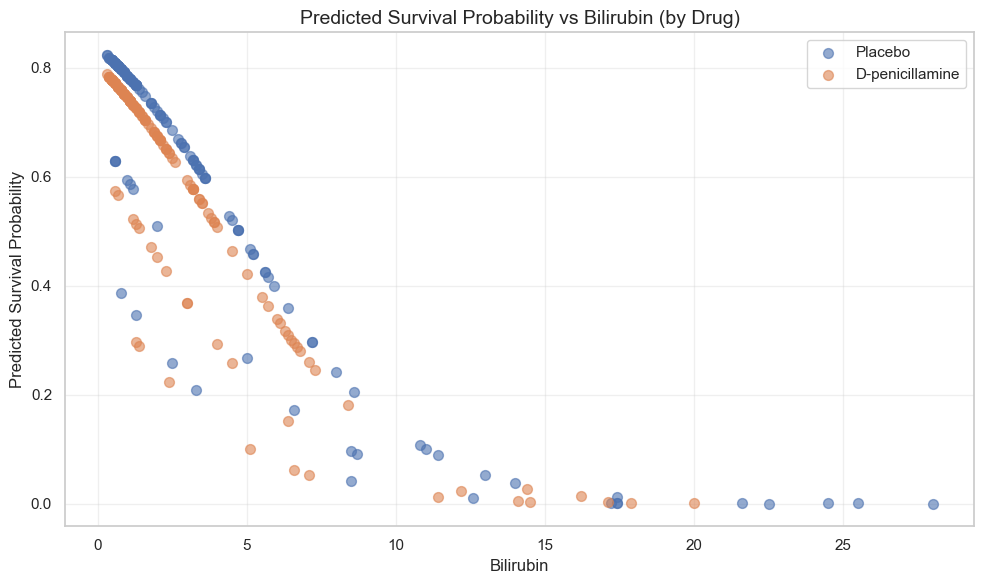


Average predicted survival probability:
  - D-penicillamine: 59.00%
  - Placebo: 60.89%
  - Average drug effect: -1.89%

Drug effect by bilirubin level:
  - Low (<1): -2.51%
  - Normal (1-2): -5.74%
  - High (2-5): -5.04%
  - Very High (>5): -0.28%

Drug provides most benefit for bilirubin level: Very High (>5)


In [40]:
#Q3.3
cirrh_df['Pred_Survival_Prob'] = log_reg_cirrh.predict_proba(X_cirrh)[:, 1]

# Scatter plot
plt.figure(figsize=(10, 6))
for drug_status in [0, 1]:
    mask = cirrh_df['Drug_Encoded'] == drug_status
    label = 'D-penicillamine' if drug_status == 1 else 'Placebo'
    plt.scatter(cirrh_df[mask]['Bilirubin'], 
               cirrh_df[mask]['Pred_Survival_Prob'],
               alpha=0.6, label=label, s=50)

plt.xlabel('Bilirubin', fontsize=12)
plt.ylabel('Predicted Survival Probability', fontsize=12)
plt.title('Predicted Survival Probability vs Bilirubin (by Drug)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#average effect of drug
drug_group = cirrh_df[cirrh_df['Drug_Encoded'] == 1]['Pred_Survival_Prob'].mean()
placebo_group = cirrh_df[cirrh_df['Drug_Encoded'] == 0]['Pred_Survival_Prob'].mean()
avg_drug_effect = drug_group - placebo_group

print(f"\nAverage predicted survival probability:")
print(f"  - D-penicillamine: {drug_group:.2%}")
print(f"  - Placebo: {placebo_group:.2%}")
print(f"  - Average drug effect: {avg_drug_effect:.2%}")

# analyze by bilirubin levels
cirrh_df['Bili_Group'] = pd.cut(cirrh_df['Bilirubin'], bins=[0, 1, 2, 5, 100], 
                                 labels=['Low (<1)', 'Normal (1-2)', 'High (2-5)', 'Very High (>5)'])
bili_effect = cirrh_df.groupby('Bili_Group').apply(
    lambda x: x[x['Drug_Encoded']==1]['Pred_Survival_Prob'].mean() - 
              x[x['Drug_Encoded']==0]['Pred_Survival_Prob'].mean()
)

print(f"\nDrug effect by bilirubin level:")
for bili, effect in bili_effect.items():
    if not np.isnan(effect):
        print(f"  - {bili}: {effect:.2%}")

if not bili_effect.isna().all():
    max_benefit_bili = bili_effect.idxmax()
    print(f"\nDrug provides most benefit for bilirubin level: {max_benefit_bili}")

In [41]:
#Q3.4
y_pred_cirrh = log_reg_cirrh.predict(X_cirrh)

cm_cirrh = confusion_matrix(y_cirrh, y_pred_cirrh)
accuracy_cirrh = accuracy_score(y_cirrh, y_pred_cirrh)

print("Q3.4: Confusion Matrix")
print("\nConfusion Matrix:")
cm_cirrh_df = pd.DataFrame(cm_cirrh, index=['Actual: Dead', 'Actual: Alive'],
columns=['Predicted: Dead', 'Predicted: Alive'])
display(cm_cirrh_df)

print(f"\nAccuracy: {accuracy_cirrh:.2%}")
print(f"\nClassification Report:")
print(classification_report(y_cirrh, y_pred_cirrh, target_names=['Dead', 'Alive']))

Q3.4: Confusion Matrix

Confusion Matrix:


,Predicted: Dead,Predicted: Alive
Actual: Dead,60,65
Actual: Alive,14,173



Accuracy: 74.68%

Classification Report:
              precision    recall  f1-score   support

        Dead       0.81      0.48      0.60       125
       Alive       0.73      0.93      0.81       187

    accuracy                           0.75       312
   macro avg       0.77      0.70      0.71       312
weighted avg       0.76      0.75      0.73       312



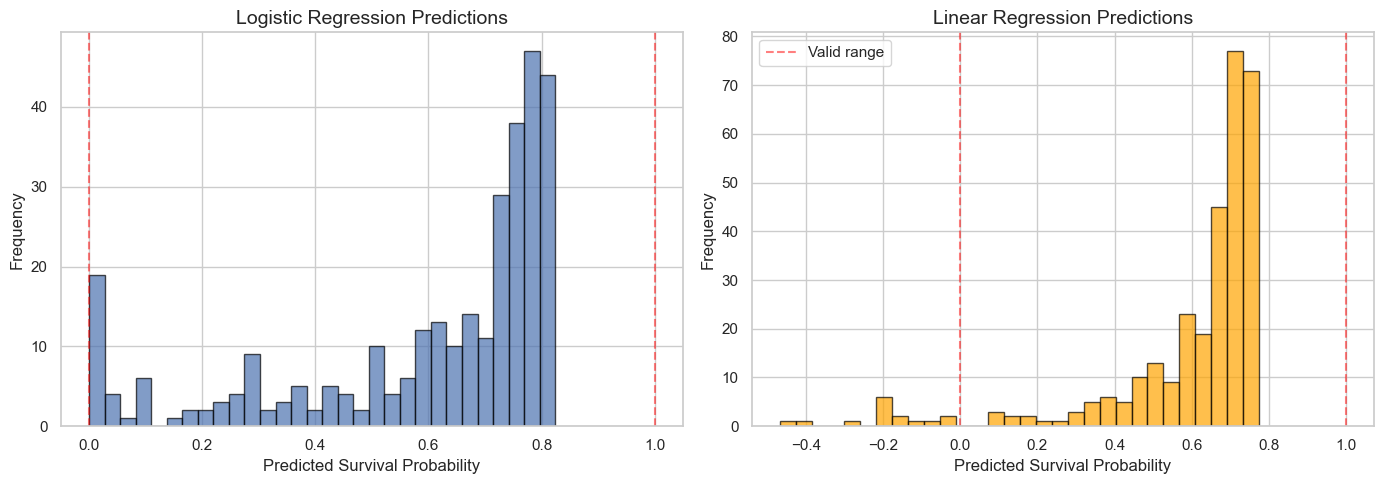


**Comparison:**

Logistic Regression:
  - Min prediction: 0.0001
  - Max prediction: 0.8242
  - All predictions in [0,1]: Yes

Linear Regression:
  - Min prediction: -0.4678
  - Max prediction: 0.7757
  - Invalid predictions (outside [0,1]): 15 (4.8%)

**Logistic regression is superior** for probability prediction as it constrains
outputs to [0,1]. Linear regression produces invalid probabilities.


In [42]:
#Q3.5
lin_reg_cirrh = LinearRegression()
lin_reg_cirrh.fit(X_cirrh, y_cirrh)
y_pred_linear_cirrh = lin_reg_cirrh.predict(X_cirrh)

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cirrh_df['Pred_Survival_Prob'], bins=30, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Predicted Survival Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Logistic Regression Predictions', fontsize=14)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(1, color='red', linestyle='--', alpha=0.5)

axes[1].hist(y_pred_linear_cirrh, bins=30, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Predicted Survival Probability', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Linear Regression Predictions', fontsize=14)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5, label='Valid range')
axes[1].axvline(1, color='red', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n**Comparison:**")
print(f"\nLogistic Regression:")
print(f"  - Min prediction: {cirrh_df['Pred_Survival_Prob'].min():.4f}")
print(f"  - Max prediction: {cirrh_df['Pred_Survival_Prob'].max():.4f}")
print(f"  - All predictions in [0,1]: Yes")

print(f"\nLinear Regression:")
print(f"  - Min prediction: {y_pred_linear_cirrh.min():.4f}")
print(f"  - Max prediction: {y_pred_linear_cirrh.max():.4f}")
invalid_cirrh = ((y_pred_linear_cirrh < 0) | (y_pred_linear_cirrh > 1)).sum()
print(f"  - Invalid predictions (outside [0,1]): {invalid_cirrh} ({invalid_cirrh/len(y_pred_linear_cirrh):.1%})")

print(f"\n**Logistic regression is superior** for probability prediction as it constrains")
print(f"outputs to [0,1]. Linear regression produces invalid probabilities.")

In [43]:
#Q3.6
X_stage = cirrh_df[['Edema_Encoded', 'Bilirubin']]
y_stage = cirrh_df['Stage']

#fit multinomial logistic regression
multi_log_reg_stage = LogisticRegression(random_state=42, max_iter=1000)
multi_log_reg_stage.fit(X_stage, y_stage)

#Hard classification
y_pred_stage = multi_log_reg_stage.predict(X_stage)

print("Q3.6: Multinomial Logistic Regression for Disease Stage")
print("\nConfusion Matrix:")
cm_stage = confusion_matrix(y_stage, y_pred_stage, labels=multi_log_reg_stage.classes_)
cm_stage_df = pd.DataFrame(cm_stage, 
                           index=[f'Actual: Stage {c}' for c in multi_log_reg_stage.classes_],
                           columns=[f'Predicted: Stage {c}' for c in multi_log_reg_stage.classes_])
display(cm_stage_df)

print(f"\nAccuracy: {accuracy_score(y_stage, y_pred_stage):.2%}")

#check predicted classes
print(f"\nClasses in hard predictions:")
print(pd.Series(y_pred_stage).value_counts().sort_index())
print(f"\nDoes hard classification predict every stage? {set(y_pred_stage) == set(multi_log_reg_stage.classes_)}")

#predicted probabilities
y_proba_stage = multi_log_reg_stage.predict_proba(X_stage)
proba_stage_df = pd.DataFrame(y_proba_stage, columns=[f'Stage {c}' for c in multi_log_reg_stage.classes_])

print(f"\nPredicted probabilities (first 10 rows):")
display(proba_stage_df.head(10))

print(f"\nProbability statistics by stage:")
display(proba_stage_df.describe())

#check if probabilities predict every class
max_proba_stage = proba_stage_df.idxmax(axis=1)
print(f"\nStages with highest probability:")
print(max_proba_stage.value_counts().sort_index())
predicted_stages = set([int(float(s.split()[-1])) for s in max_proba_stage.unique()])
print(f"\nDo predicted probabilities predict every stage? {predicted_stages == set(multi_log_reg_stage.classes_)}")

print(f"\n**Analysis:**")
if set(y_pred_stage) != set(multi_log_reg_stage.classes_):
    missing = set(multi_log_reg_stage.classes_) - set(y_pred_stage)
    print(f"Hard classification does NOT predict all stages. Missing: Stage {missing}")
    print(f"The model may struggle to distinguish certain disease stages.")
else:
    print(f"Hard classification predicts all stages.")

if predicted_stages != set(multi_log_reg_stage.classes_):
    missing = set(multi_log_reg_stage.classes_) - predicted_stages
    print(f"\nProbabilities do NOT predict all stages as most likely. Missing: Stage {missing}")
else:
    print(f"\nProbabilities predict all stages as most likely for at least some patients.")

Q3.6: Multinomial Logistic Regression for Disease Stage

Confusion Matrix:


,Predicted: Stage 1.0,Predicted: Stage 2.0,Predicted: Stage 3.0,Predicted: Stage 4.0
Actual: Stage 1.0,0,0,16,0
Actual: Stage 2.0,0,0,61,6
Actual: Stage 3.0,0,0,102,18
Actual: Stage 4.0,0,0,74,35



Accuracy: 43.91%

Classes in hard predictions:
3.0    253
4.0     59
Name: count, dtype: int64

Does hard classification predict every stage? False

Predicted probabilities (first 10 rows):


,Stage 1.0,Stage 2.0,Stage 3.0,Stage 4.0
0,3.6617e-06,0.0262,0.1638,0.8100
1,7.3533e-02,0.2529,0.4010,0.2726
2,2.6874e-02,0.1721,0.3377,0.4634
3,2.1408e-02,0.1674,0.3384,0.4728
4,2.0987e-02,0.2278,0.4281,0.3230
5,8.5983e-02,0.2545,0.3948,0.2647
6,7.7488e-02,0.2535,0.3990,0.2700
7,1.1097e-01,0.2558,0.3824,0.2507
8,2.3467e-02,0.2305,0.4268,0.3191
9,1.1620e-05,0.0322,0.1747,0.7931



Probability statistics by stage:


,Stage 1.0,Stage 2.0,Stage 3.0,Stage 4.0
count,3.1200e+02,312.0000,312.0000,312.0000
mean,5.1323e-02,0.2147,0.3846,0.3493
std,3.6407e-02,0.0636,0.0608,0.1402
min,3.3262e-09,0.0108,0.1220,0.2507
25%,1.5850e-02,0.1964,0.3877,0.2647
50%,5.4922e-02,0.2485,0.3990,0.2861
75%,8.5983e-02,0.2545,0.4181,0.3629
max,1.1097e-01,0.2558,0.4349,0.8672



Stages with highest probability:
Stage 3.0    253
Stage 4.0     59
Name: count, dtype: int64

Do predicted probabilities predict every stage? False

**Analysis:**
Hard classification does NOT predict all stages. Missing: Stage {np.float64(1.0), np.float64(2.0)}
The model may struggle to distinguish certain disease stages.

Probabilities do NOT predict all stages as most likely. Missing: Stage {np.float64(1.0), np.float64(2.0)}


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule ($D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

Q4.1

For the linear model:
$$
\hat{y} = b_0 + \sum_{k=1}^K b_k x_k
$$

The derivative with respect to the $k$-th feature is:
$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

Interpretation:
- For a 1-unit change in $x_k$, the prediction changes by exactly $b_k$
- This relationship is constant it doesn't depend on the values of other features
- The coefficient $b_k$ directly represents the marginal effect of feature $k$

If $b_k = 0.5$, then increasing $x_k$ by 1 unit increases $\hat{y}$ by 0.5 units, regardless of the current value of $x_k$ or other features.

Q4.2

For the logistic model:
$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

where $b \cdot x = b_0 + \sum_{k=1}^K b_k x_k$.

Using the chain rule and the hint:
$$
\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial \hat{p}}{\partial (b \cdot x)} \cdot \frac{\partial (b \cdot x)}{\partial x_k}
$$

From the hint:
$$
\frac{\partial \hat{p}}{\partial (b \cdot x)} = \hat{p}(1 - \hat{p})
$$

And:
$$
\frac{\partial (b \cdot x)}{\partial x_k} = b_k
$$

Therefore:
$$
{\frac{\partial \hat{p}}{\partial x_k} = b_k \cdot \hat{p}(1 - \hat{p})}
$$

Key Differences from Linear Model:
1. Non-constant effect: The marginal effect depends on the current probability $\hat{p}$
2. Maximum at $\hat{p} = 0.5$: The term $\hat{p}(1-\hat{p})$ is maximized when $\hat{p} = 0.5$, where it equals 0.25
3. Diminishing at extremes: When $\hat{p}$ is near 0 or 1, the effect of changing $x_k$ is small

When is $b_k$ (times 4) a good approximation?

When $\hat{p} \approx 0.5$:
$$
\frac{\partial \hat{p}}{\partial x_k} = b_k \cdot 0.5 \cdot 0.5 = 0.25 b_k = \frac{b_k}{4}
$$

so
$$
\frac{\partial \hat{p}}{\partial x_k} \approx \frac{b_k}{4} \quad \text{when } \hat{p} \approx 0.5
$$

Or equivalently, $4 \cdot \frac{\partial \hat{p}}{\partial x_k} \approx b_k$ when $\hat{p} \approx 0.5$.

interpretation: Near $\hat{p} = 0.5$, the coefficient divided by 4 approximates the change in probability for a 1-unit change in $x_k$.

Q4.3

Starting from:
$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

We can derive:

$$
\begin{aligned}
\hat{p}(1 + e^{b \cdot x}) &= e^{b \cdot x} \\
\hat{p} + \hat{p} e^{b \cdot x} &= e^{b \cdot x} \\
\hat{p} &= e^{b \cdot x} - \hat{p} e^{b \cdot x} \\
\hat{p} &= (1 - \hat{p}) e^{b \cdot x} \\
\frac{\hat{p}}{1 - \hat{p}} &= e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1 - \hat{p}} \right) &= b \cdot x = b_0 + \sum_{k=1}^K b_k x_k
\end{aligned}
$$

The log odds ratio (also called the logit) is:
$$
\text{logit}(\hat{p}) = \log \left( \frac{\hat{p}}{1 - \hat{p}} \right)
$$

Effect of a 1-unit change in $x_k$:

Taking the derivative:
$$
\frac{\partial}{\partial x_k} \log \left( \frac{\hat{p}}{1 - \hat{p}} \right) = \frac{\partial}{\partial x_k} \left( b_0 + \sum_{j=1}^K b_j x_j \right) = b_k
$$

Interpretation:
$$
{\text{A 1-unit increase in } x_k \text{ increases the log odds by } b_k}
$$

Since $\log(\text{odds}) = b \cdot x$, we have $\text{odds} = e^{b \cdot x}$.

A 1-unit increase in $x_k$ multiplies the odds by $e^{b_k}$:
$$
\text{odds}_{\text{new}} = e^{b_0 + \cdots + b_k(x_k + 1) + \cdots} = e^{b_k} \cdot e^{b_0 + \cdots + b_k x_k + \cdots} = e^{b_k} \cdot \text{odds}_{\text{old}}
$$

Summary:
- Log odds interpretation: A 1-unit increase in $x_k$ adds $b_k$ to the log odds
- Odds ratio interpretation: A 1-unit increase in $x_k$ multiplies the odds by $e^{b_k}$
- This is why we often report odds ratios ($e^{b_k}$) in logistic regression:
  - $e^{b_k} > 1$: feature increases odds of positive outcome
  - $e^{b_k} < 1$: feature decreases odds of positive outcome
  - $e^{b_k} = 1$: feature has no effect on odds